# NLP graphs for my SheriaBot project

I'm running the NLP pipeline on my SheriaBot dataset (stages 4, 11, 12, 13, 14, 15, 16) and plotting the graphs I need for the report.

Data: 8100 legal questions in Swahili + English + a bit of mixed, labelled with 16 intent classes (dismissal_complaint, wage_underpayment, cma_filing, etc). The file is data/04_Intents.csv which I exported earlier from the curriculum spreadsheet.

Graphs are saved to ../graphs/ as PNGs so I can drop them into Word.

Notes about the data:
- text mixes Swahili and English
- NLTK POS/NER only work well on English tokens, so those charts are a bit rough on the Swahili side
- Word2Vec should still learn bilingual similarity because the corpus is small and topical
- for stage 16 I use the multilingual DistilBERT tokenizer since my data isn't English-only

## Setup

In [ ]:
import os
os.environ["USE_TF"] = "0"

import warnings
warnings.filterwarnings("ignore")

import re, string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# where the graphs get written
DATA_DIR   = Path("data")
GRAPHS_DIR = Path("graphs")
GRAPHS_DIR.mkdir(exist_ok=True)

def save_and_show(name):
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("saved:", GRAPHS_DIR / (name + ".png"))

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
print("setup done. graphs go to:", GRAPHS_DIR.resolve())

In [ ]:
import nltk
for r in ["punkt", "punkt_tab", "stopwords", "wordnet",
          "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
          "maxent_ne_chunker", "maxent_ne_chunker_tab", "words", "omw-1.4"]:
    nltk.download(r, quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag, ne_chunk

# NLTK english stopwords + a handful of swahili ones I added
STOP_EN = set(stopwords.words("english"))
STOP_SW = {
    "na","ya","wa","ni","kwa","za","la","ku","katika","hii","hiyo","kama",
    "tu","pia","yangu","yako","yake","yenu","yao","ndani","nje","juu","chini",
    "hapa","huko","huku","kabisa","tayari","bado","siku","mwezi","mwaka",
    "mimi","wewe","yeye","sisi","nyinyi","wao","mtu","watu","kitu","vitu",
    "je","nini","gani","lini","wapi","vipi","kiasi","ngapi","nani",
}
STOPWORDS = STOP_EN | STOP_SW
print(f"stopwords: {len(STOP_EN)} EN + {len(STOP_SW)} SW = {len(STOPWORDS)}")

In [ ]:
# load my intents csv
df = pd.read_csv(DATA_DIR / "04_Intents.csv")
print("rows:", len(df), " cols:", list(df.columns))

# rename columns so they're shorter
df = df.rename(columns={"utterance": "text", "intent_label": "intent"})
df["length"] = df["text"].astype(str).apply(len)
df.head(3)

In [ ]:
# same clean function as IMDB but I keep accented characters in case they matter for swahili
def clean_text(t):
    t = re.sub(r"\[.*?\]", " ", str(t))                # drop bracket annotations
    t = re.sub(r"http\S+|www\S+", " ", t)              # drop urls
    t = re.sub(r"[0-9]+", " ", t.lower())                # drop digits
    t = re.sub(r"[^a-z\u00c0-\u017f\s]", " ", t)      # only keep letters
    return re.sub(r"\s+", " ", t).strip()

df["clean"] = df["text"].apply(clean_text)
df[["text","clean","lang","intent"]].sample(3, random_state=42)

---

## Stage 4 - EDA

Looking at the data first. Class balance, language mix, sentence lengths, data quality.

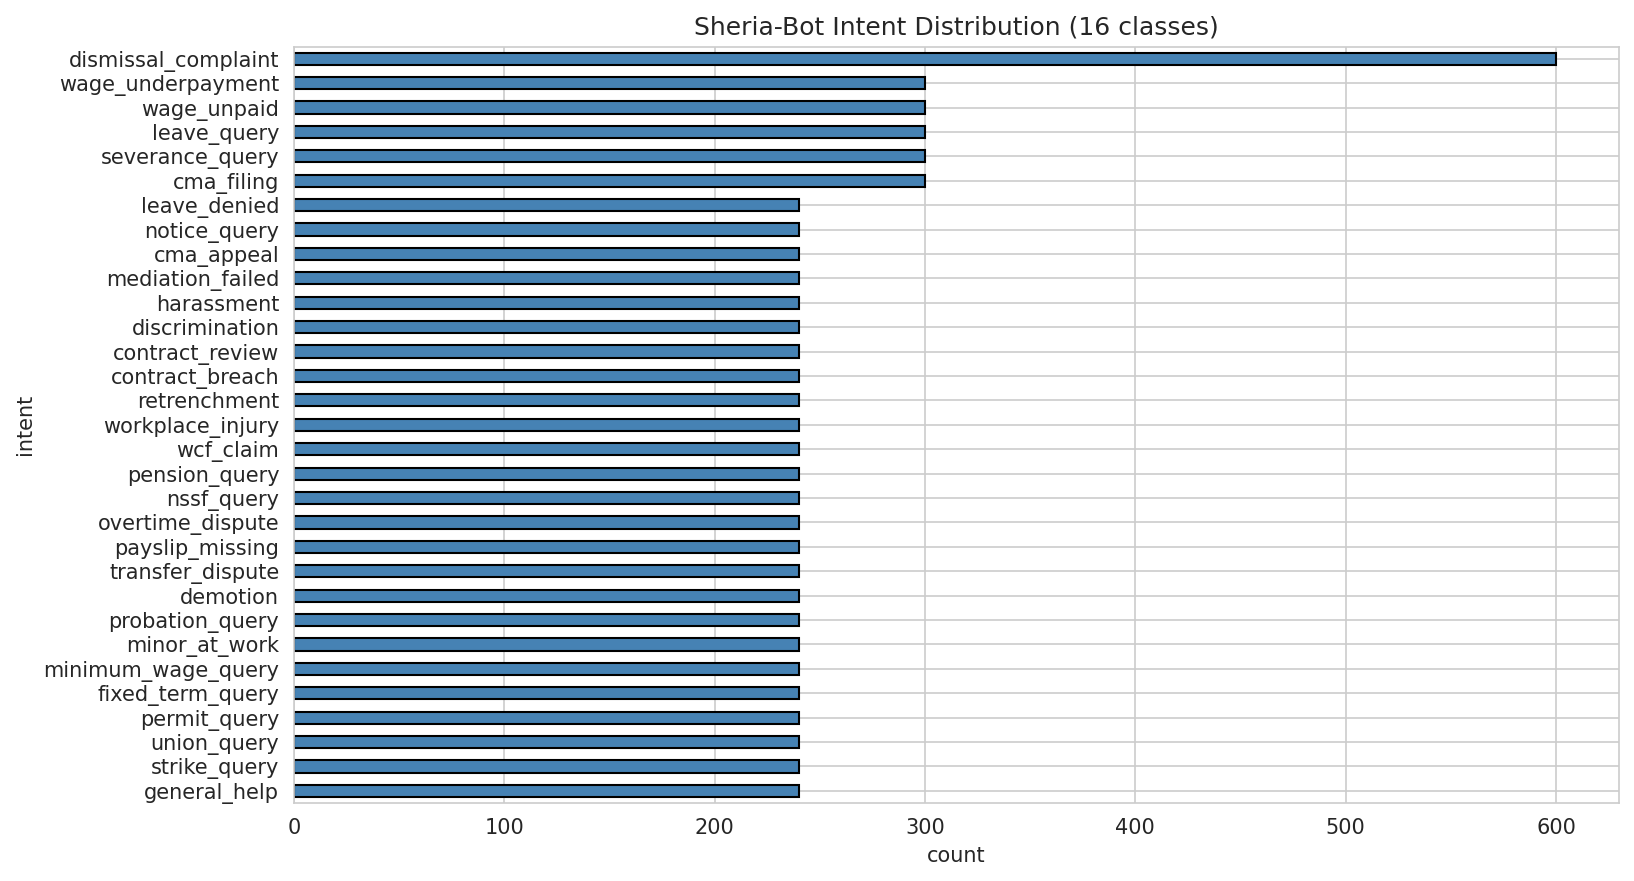

In [ ]:
# 4.1 - class distribution
intent_counts = df["intent"].value_counts()
plt.figure(figsize=(11, 6))
intent_counts.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Sheria-Bot Intent Distribution (16 classes)")
plt.xlabel("count"); plt.ylabel("intent")
plt.gca().invert_yaxis()
save_and_show("stage04_class_distribution")

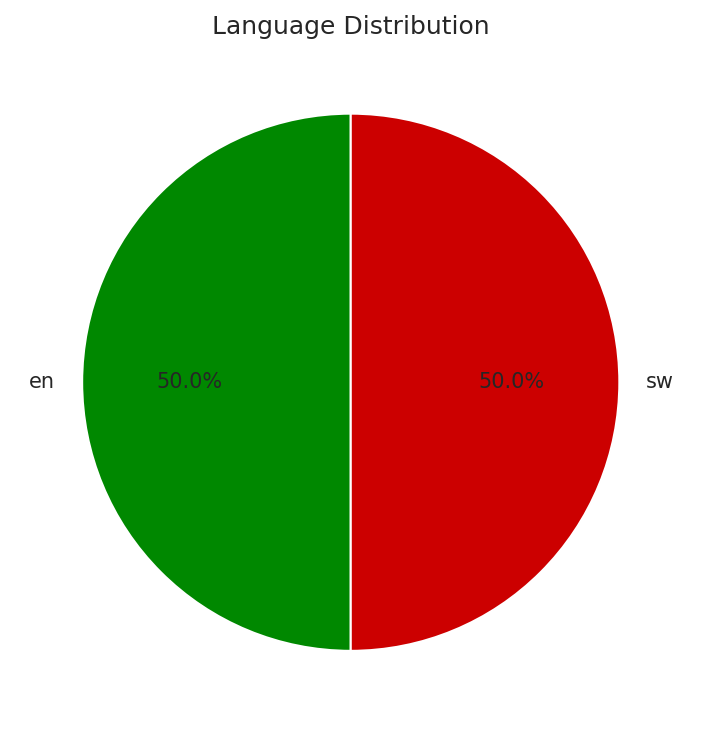

In [ ]:
# 4.2 - language pie
lang_counts = df["lang"].value_counts()
plt.figure(figsize=(6, 5))
plt.pie(lang_counts.values, labels=lang_counts.index, autopct="%1.1f%%",
        colors=["#080","#c00","#c60"], startangle=90)
plt.title("Language Distribution")
save_and_show("stage04_language_distribution")

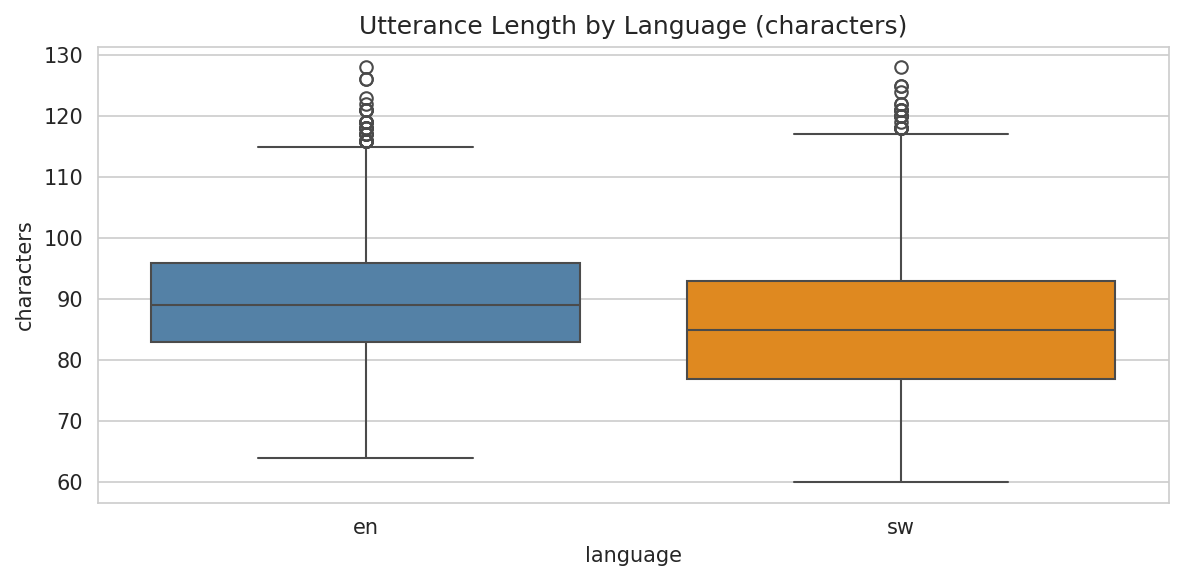

In [ ]:
# 4.3 - length by language
plt.figure(figsize=(8, 4))
sns.boxplot(x="lang", y="length", data=df, palette=["steelblue","darkorange","teal"])
plt.title("Utterance Length by Language (characters)")
plt.xlabel("language"); plt.ylabel("characters")
save_and_show("stage04_length_by_language")

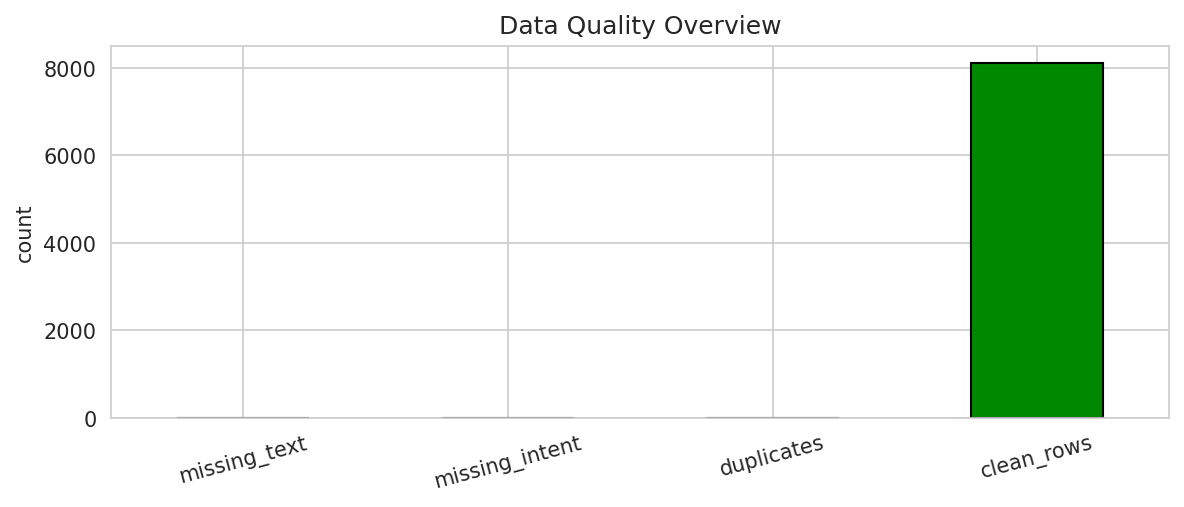

In [ ]:
# 4.4 - quick data quality check
stats = pd.Series({
    "missing_text":   df["text"].isna().sum(),
    "missing_intent": df["intent"].isna().sum(),
    "duplicates":     df.duplicated(subset=["clean"]).sum(),
    "clean_rows":     len(df),
})
plt.figure(figsize=(8, 3.5))
stats.plot.bar(color=["#c00","#c00","#c60","#080"], edgecolor="black")
plt.title("Data Quality Overview")
plt.ylabel("count"); plt.xticks(rotation=15)
save_and_show("stage04_data_quality")

---

## Stage 11 - POS tagging

Running NLTK's english POS tagger on a random sample of 500 utterances. Swahili tokens get tagged wrong (mostly NN) but the chart still shows the grammatical make-up.

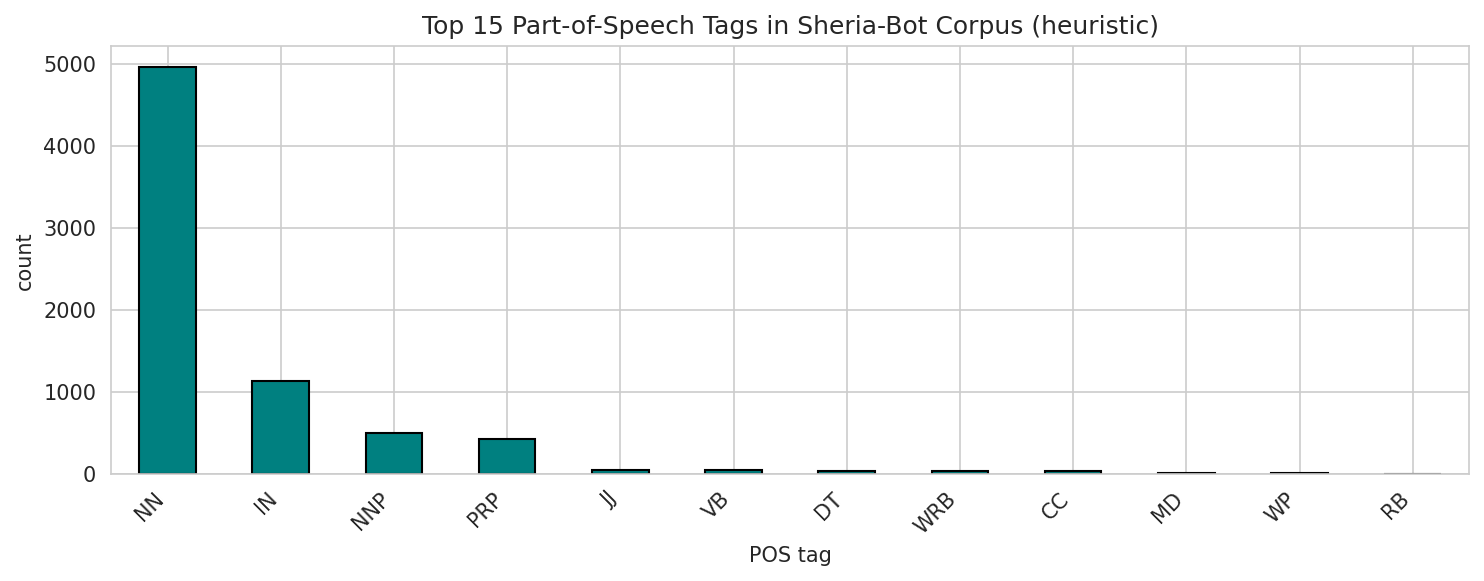

In [ ]:
# POS tag counts
all_tags = []
for text in df["clean"].sample(500, random_state=42):
    all_tags.extend(tag for _, tag in pos_tag(word_tokenize(text)))

top_tags = pd.Series(all_tags).value_counts().head(15)
plt.figure(figsize=(10, 4))
top_tags.plot.bar(color="teal", edgecolor="black")
plt.title("Top 15 POS Tags in the corpus")
plt.xlabel("POS tag"); plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
save_and_show("stage11_pos_distribution")

# just so I remember what each abbreviation means
POS_MEANING = {
    "NN":"noun (singular)", "NNS":"noun (plural)", "NNP":"proper noun",
    "JJ":"adjective", "VB":"verb (base)", "VBD":"verb (past)", "VBG":"verb (-ing)",
    "VBN":"verb (past participle)", "VBP":"verb (present)", "VBZ":"verb (3rd sg)",
    "RB":"adverb", "IN":"preposition", "DT":"determiner", "PRP":"pronoun",
    "CC":"conjunction", "CD":"cardinal number", "TO":"to",
}
for t, count in top_tags.items():
    print(f"  {t:5s} {count:>5}  ->  {POS_MEANING.get(t, '?')}")

---

## Stage 12 - Named Entity Recognition

NLTK NER only really catches english proper nouns, so it picks up things like CMA, ELRA, city names, common names.

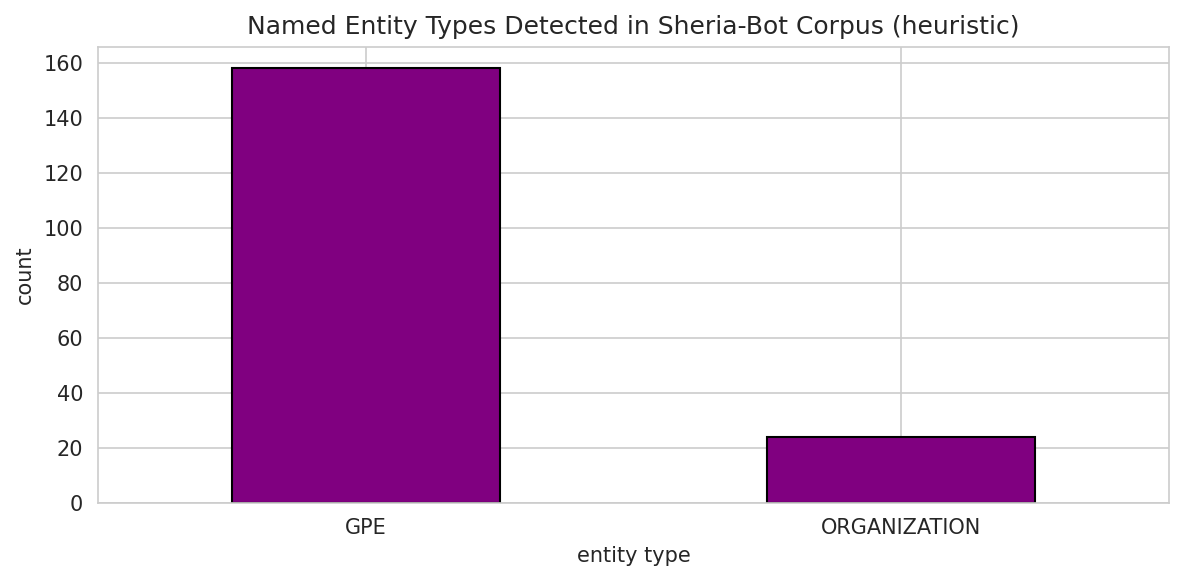

In [ ]:
# named entity types
entity_counts = Counter()
entity_examples = {}          # keep one example per type

for text in df["text"].sample(400, random_state=42):
    try:
        tree = ne_chunk(pos_tag(word_tokenize(str(text))))
    except Exception:
        continue
    for sub in tree:
        if hasattr(sub, "label"):
            lbl = sub.label()
            entity_counts[lbl] += 1
            if lbl not in entity_examples:
                entity_examples[lbl] = " ".join(w for w, _ in sub.leaves())

entity_series = pd.Series(entity_counts).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
entity_series.plot.bar(color="purple", edgecolor="black")
plt.title("Named Entity Types found")
plt.xlabel("entity type"); plt.ylabel("count")
plt.xticks(rotation=0)
save_and_show("stage12_ner_types")

print("examples of each entity type:")
for lbl, ex in entity_examples.items():
    print(f"  {lbl:15s}  '{ex}'")

---

## Stage 13 - text visualisation

Top word frequencies, a wordcloud, and comparing top words between the two most common intents.

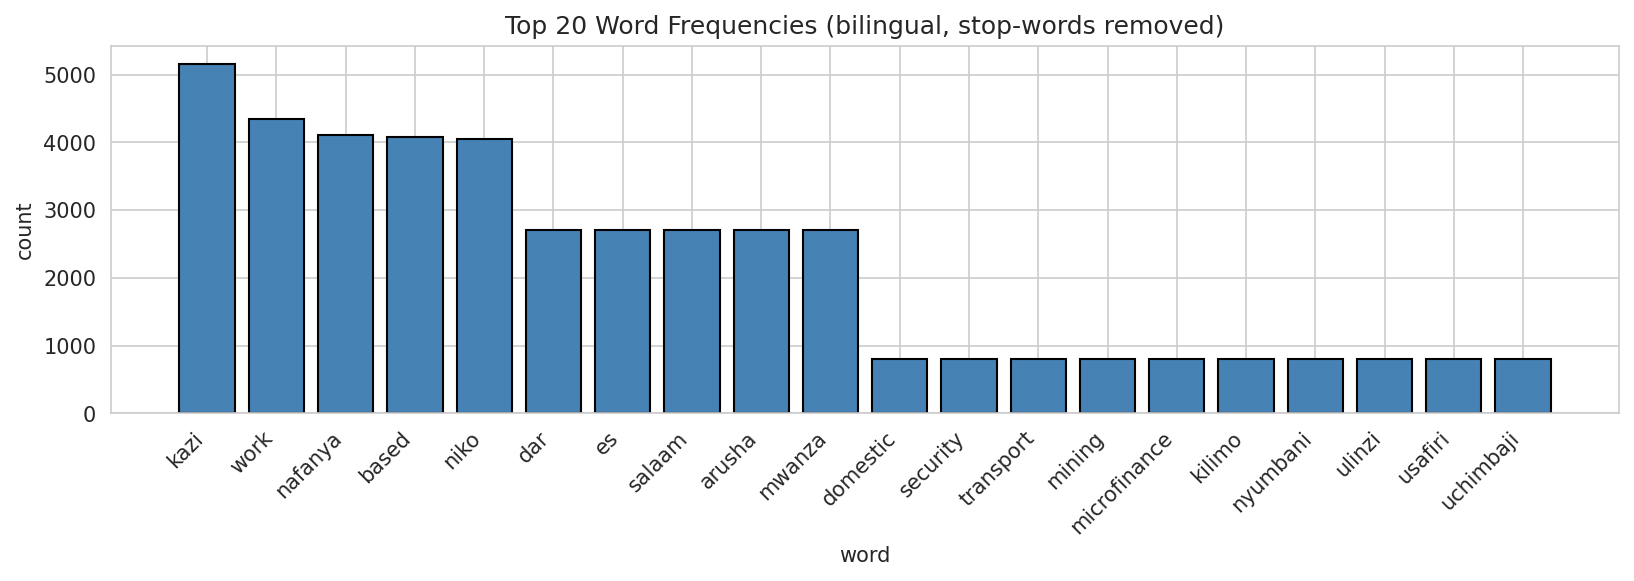

In [ ]:
# 13.1 - top 20 words (bilingual, stopwords removed)
all_tokens = []
for txt in df["clean"]:
    all_tokens.extend(w for w in word_tokenize(txt) if w.isalpha() and w not in STOPWORDS)

freq = Counter(all_tokens)
top20 = pd.DataFrame(freq.most_common(20), columns=["word", "count"])

plt.figure(figsize=(11, 4))
plt.bar(top20["word"], top20["count"], color="steelblue", edgecolor="black")
plt.title("Top 20 Word Frequencies (bilingual)")
plt.xlabel("word"); plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
save_and_show("stage13_top_words")

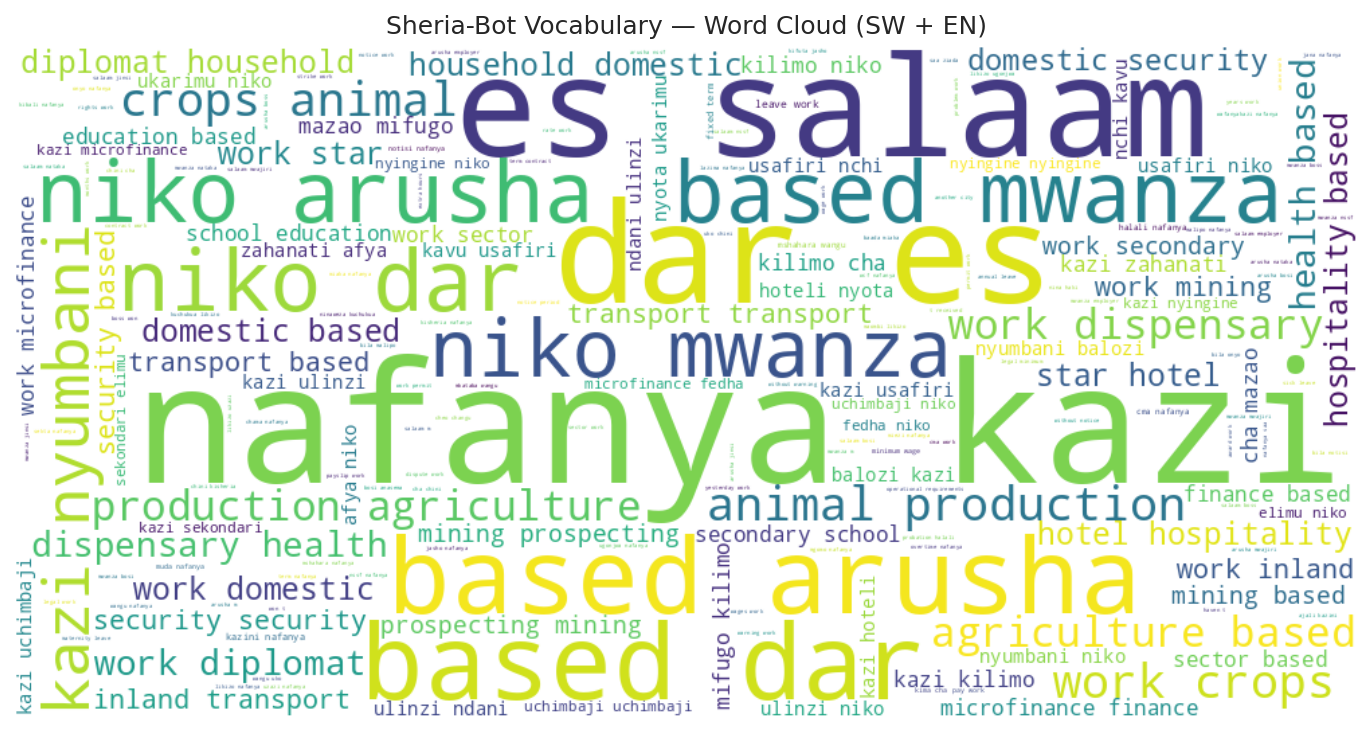

In [ ]:
# 13.2 - word cloud
from wordcloud import WordCloud
text_blob = " ".join(all_tokens)
wc = WordCloud(background_color="white", width=1000, height=500,
               colormap="viridis", max_words=200).generate(text_blob)
plt.figure(figsize=(11, 5))
plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
plt.title("SheriaBot vocabulary wordcloud")
save_and_show("stage13_wordcloud")

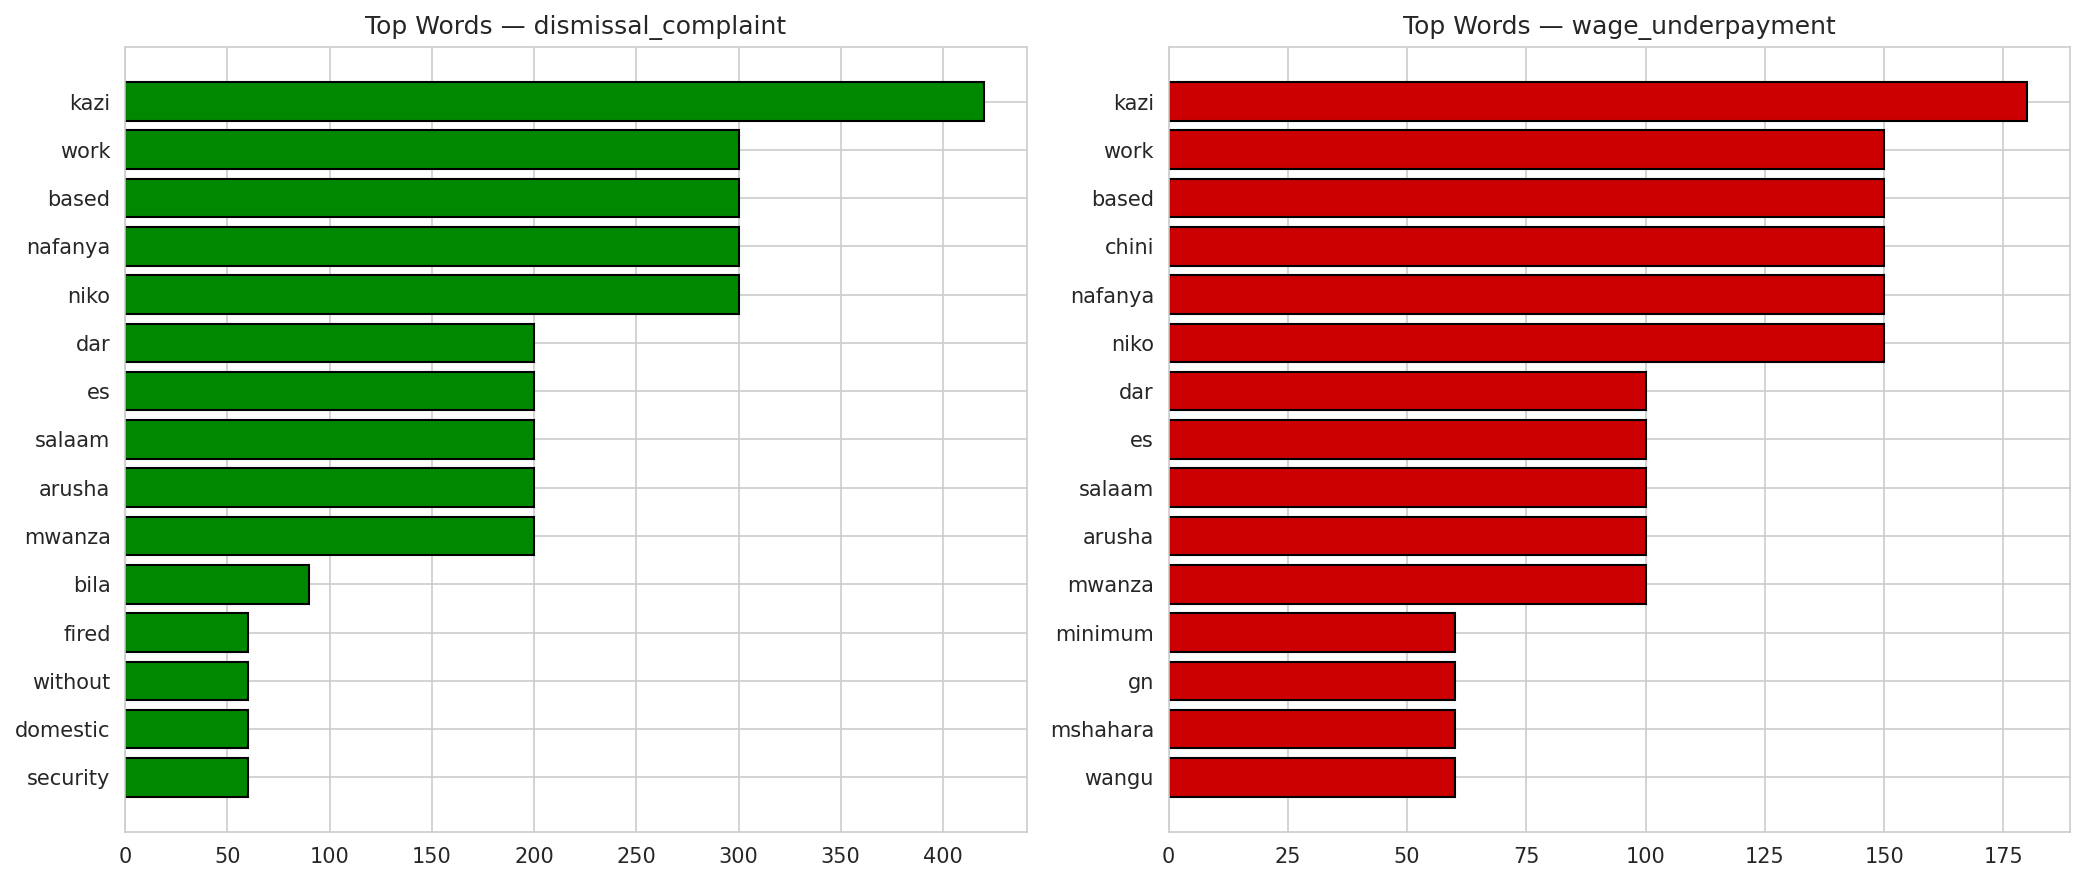

In [ ]:
# 13.3 - top words for the two biggest intents, side by side
def top_words(rows, n=15):
    ws = []
    for r in rows:
        ws.extend(w for w in word_tokenize(r) if w.isalpha() and w not in STOPWORDS)
    return pd.DataFrame(Counter(ws).most_common(n), columns=["word","count"])

top_intents = intent_counts.head(2).index.tolist()
a = top_words(df[df.intent == top_intents[0]].clean)
b = top_words(df[df.intent == top_intents[1]].clean)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].barh(a["word"], a["count"], color="#080", edgecolor="black")
ax[0].set_title(f"top words - {top_intents[0]}")
ax[0].invert_yaxis()
ax[1].barh(b["word"], b["count"], color="#c00", edgecolor="black")
ax[1].set_title(f"top words - {top_intents[1]}")
ax[1].invert_yaxis()
save_and_show("stage13_top_words_by_intent")

---

## Stage 14 - feature engineering

BoW + TF-IDF.

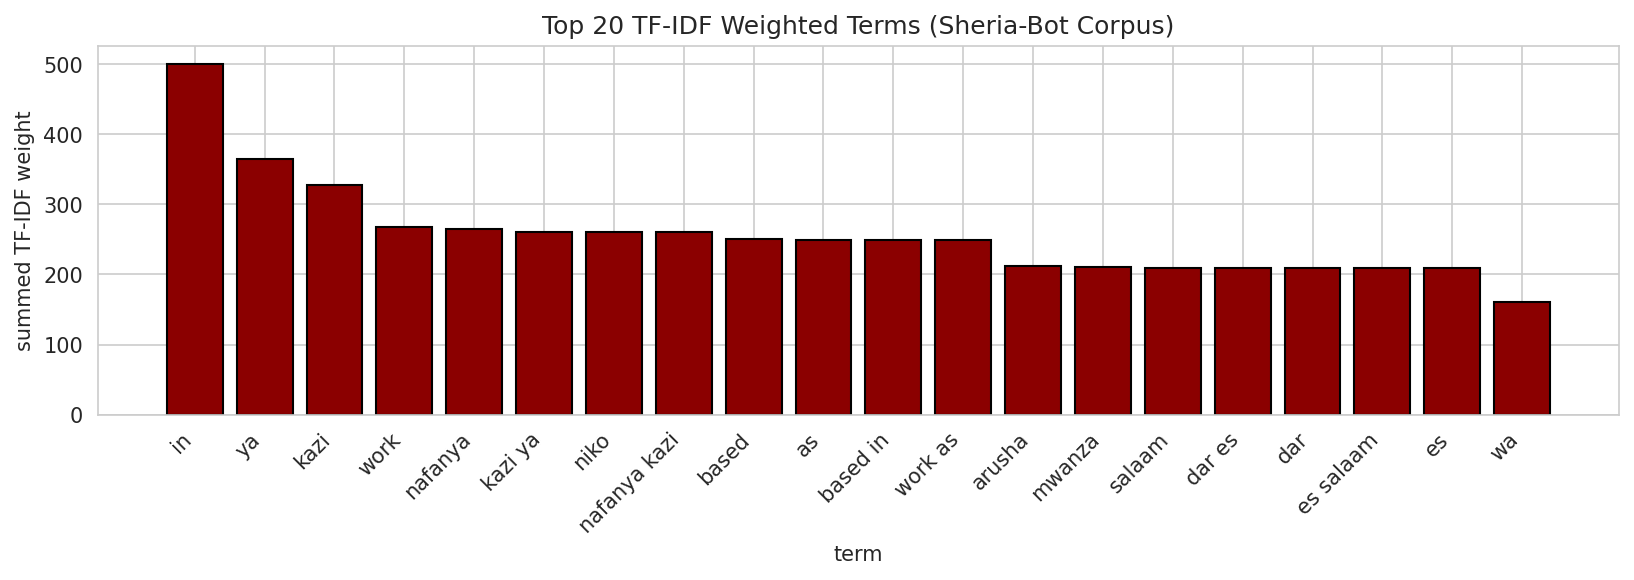

In [ ]:
# 14.1 - top TF-IDF terms
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean"], df["intent"], test_size=0.2, random_state=42, stratify=df["intent"]
)

bow_vec = CountVectorizer(max_features=5000)
bow_vec.fit(X_train_text)

tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)

tfidf_sum = np.asarray(X_train_tfidf.sum(axis=0)).ravel()
top_idx = tfidf_sum.argsort()[::-1][:20]
top_terms  = np.array(tfidf_vec.get_feature_names_out())[top_idx]
top_scores = tfidf_sum[top_idx]

plt.figure(figsize=(11, 4))
plt.bar(top_terms, top_scores, color="darkred", edgecolor="black")
plt.title("Top 20 TF-IDF Terms")
plt.xlabel("term"); plt.ylabel("summed TF-IDF weight")
plt.xticks(rotation=45, ha="right")
save_and_show("stage14_tfidf_top_terms")

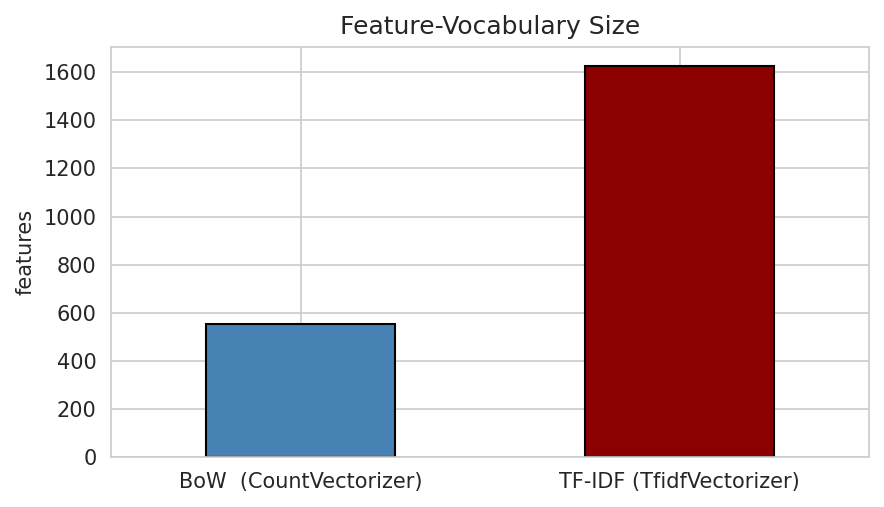

In [ ]:
# 14.2 - just to see, BoW vs TF-IDF vocab
sizes = pd.Series({
    "BoW":   len(bow_vec.get_feature_names_out()),
    "TFIDF": len(tfidf_vec.get_feature_names_out()),
})
plt.figure(figsize=(6, 3.5))
sizes.plot.bar(color=["steelblue", "darkred"], edgecolor="black")
plt.title("Vocabulary size")
plt.ylabel("features")
plt.xticks(rotation=0)
save_and_show("stage14_vocab_size")

---

## Stage 15 - Word2Vec embeddings

Training Word2Vec on the cleaned corpus then plotting 100 word vectors with PCA. If it worked, swahili and english translations should sit close (kufukuzwa ~ dismissed, mshahara ~ wage).

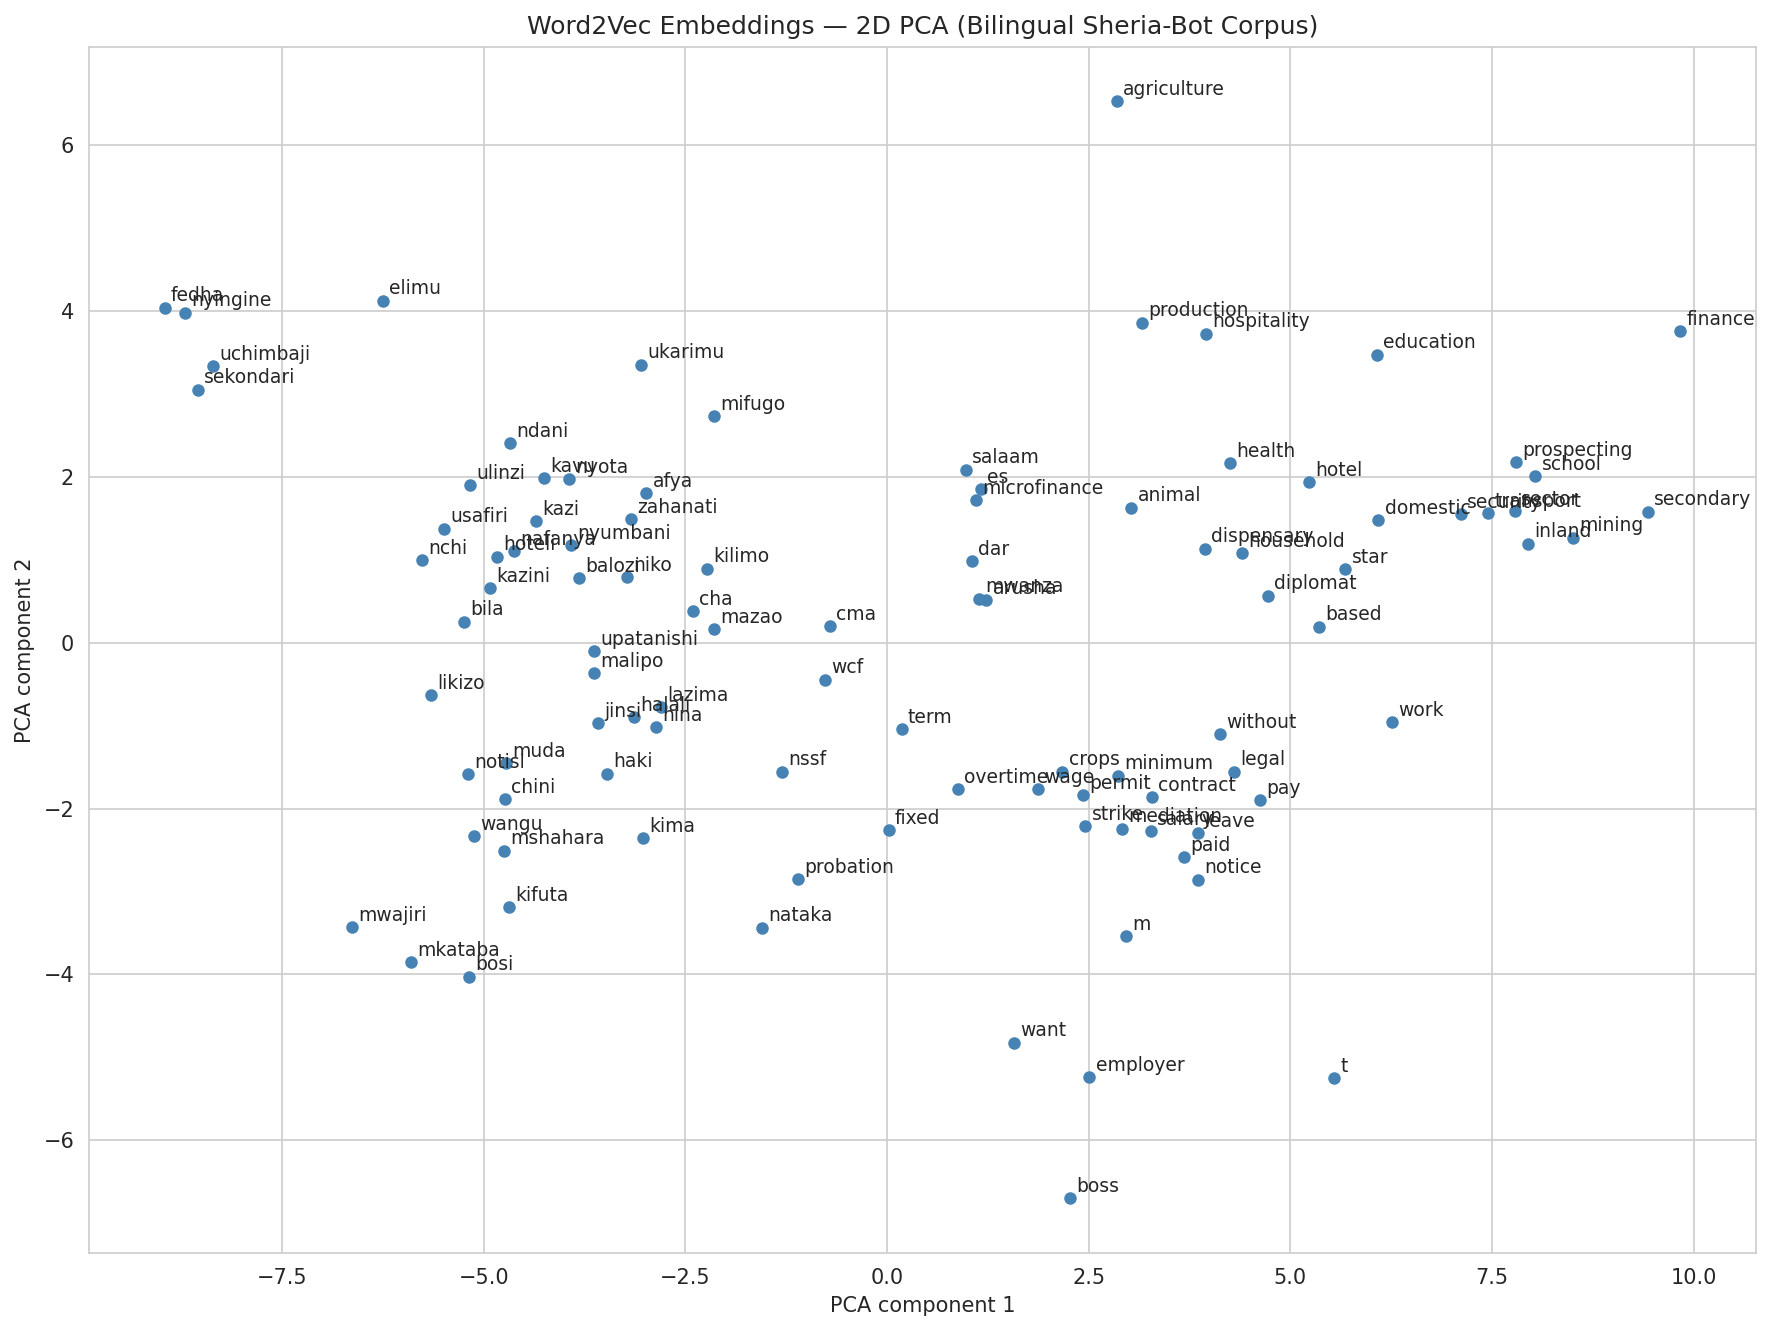

In [ ]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

tokenized_corpus = [word_tokenize(t) for t in df["clean"]]
w2v = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5,
               min_count=5, workers=1, seed=42, epochs=15)

words = [w for w in w2v.wv.key_to_index
         if w.isalpha() and w not in STOPWORDS][:100]
vectors = np.array([w2v.wv[w] for w in words])
coords  = PCA(n_components=2, random_state=42).fit_transform(vectors)

plt.figure(figsize=(12, 9))
plt.scatter(coords[:, 0], coords[:, 1], s=25, c="steelblue")
for i, w in enumerate(words):
    plt.annotate(w, (coords[i, 0], coords[i, 1]),
                 fontsize=9, xytext=(3, 3), textcoords="offset points")
plt.title("Word2Vec embeddings in 2D (PCA)")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
save_and_show("stage15_word2vec_pca")

# quick sanity check - similar words for a few legal terms
print("some similar words:")
for w in ["kufukuzwa", "dismissed", "mshahara", "wage", "cma", "elra"]:
    if w in w2v.wv:
        sims = w2v.wv.most_similar(w, topn=5)
        print(f"  '{w}' -> {[(s, round(sc,3)) for s, sc in sims]}")

---

## Stage 16 - Transformer tokenisation

Using the multilingual DistilBERT tokenizer since my text isn't english-only. Comparing NLTK word count vs BERT subword count per utterance.

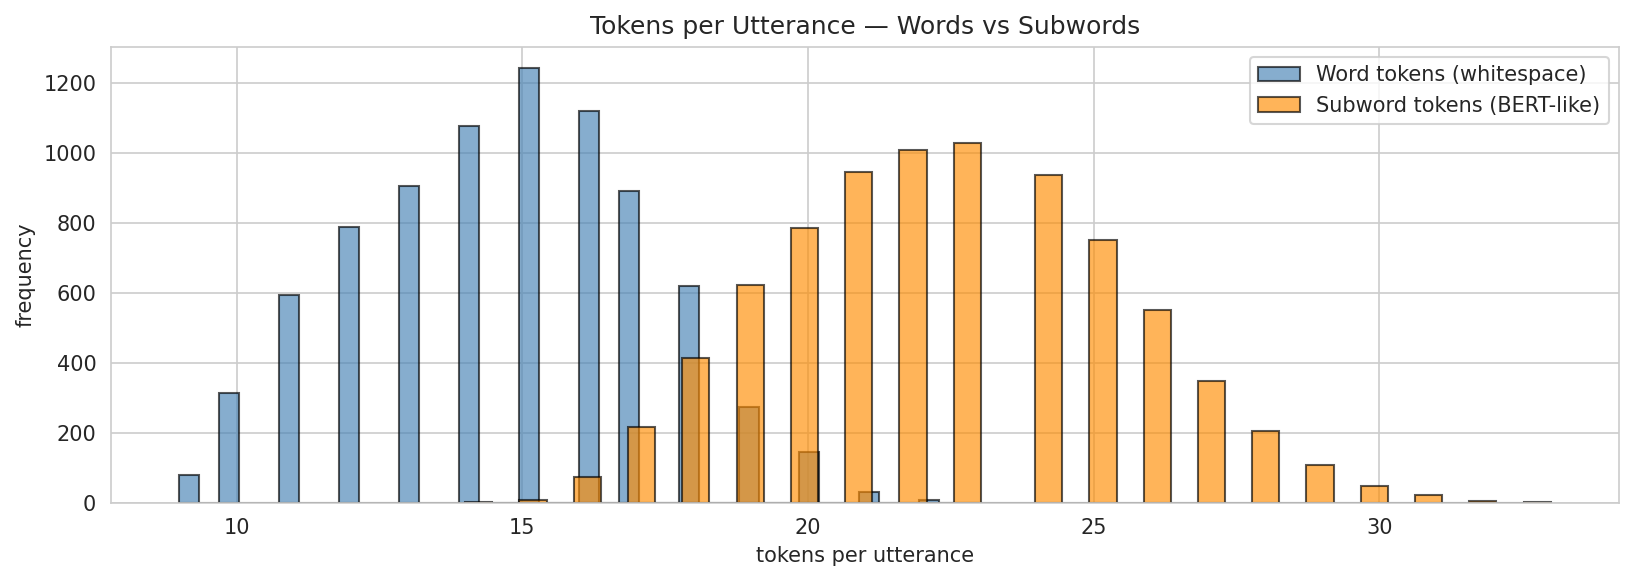

In [ ]:
# 16.1 - word vs subword histogram
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-multilingual-cased"
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

word_lens = df["clean"].apply(lambda t: len(word_tokenize(t)))
enc = tok(df["clean"].tolist(), truncation=False)["input_ids"]
sub_lens = pd.Series([len(x) for x in enc])

plt.figure(figsize=(11, 4))
plt.hist(word_lens, bins=40, alpha=0.65, label="NLTK words",   color="steelblue", edgecolor="black")
plt.hist(sub_lens,  bins=40, alpha=0.65, label="BERT subword", color="darkorange", edgecolor="black")
plt.legend()
plt.title("Tokens per utterance: NLTK words vs BERT subwords")
plt.xlabel("tokens"); plt.ylabel("frequency")
save_and_show("stage16_word_vs_subword")

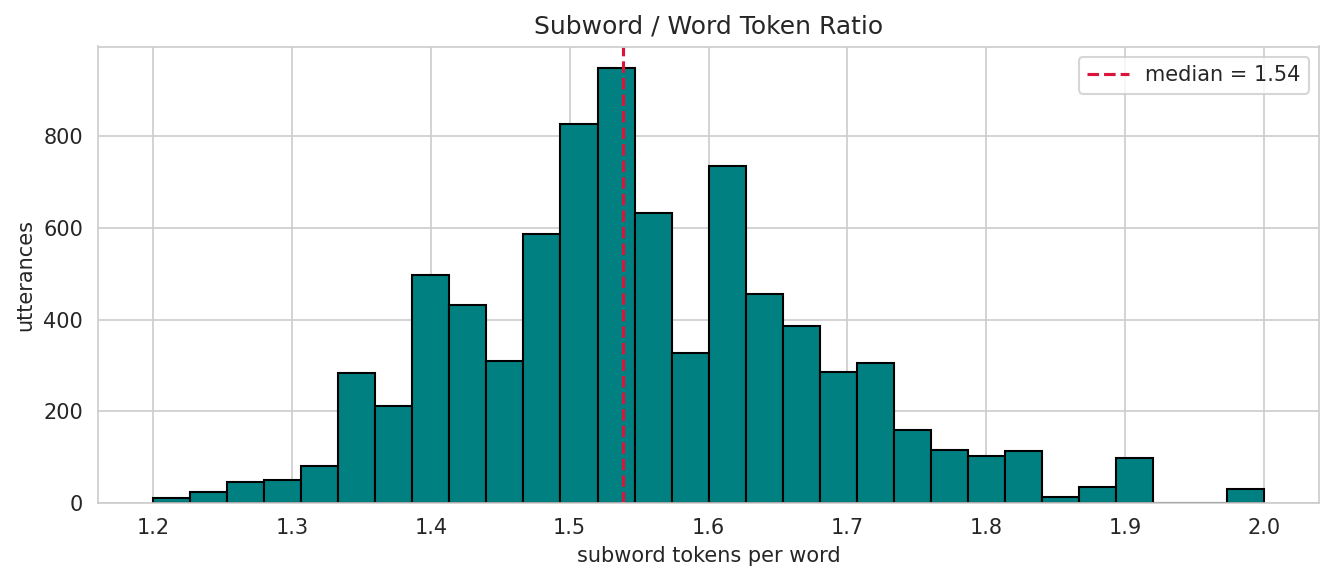

In [ ]:
# 16.2 - subword / word ratio
ratio = sub_lens / word_lens.replace(0, np.nan)
plt.figure(figsize=(9, 4))
plt.hist(ratio.dropna(), bins=30, color="teal", edgecolor="black")
plt.axvline(ratio.median(), color="crimson", linestyle="--",
            label=f"median = {ratio.median():.2f}")
plt.legend()
plt.title("Subword / word ratio")
plt.xlabel("subword tokens per NLTK word"); plt.ylabel("utterances")
save_and_show("stage16_subword_ratio")

print(f"average ratio: {ratio.mean():.2f}")
print(f"median: {ratio.median():.2f}")

---

## done, list every saved graph

In [ ]:
for f in sorted(GRAPHS_DIR.glob("*.png")):
    print(f)
print(f"\ntotal: {len(list(GRAPHS_DIR.glob('*.png')))} graphs in {GRAPHS_DIR.resolve()}")